In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
si = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata/MutWP1_CRC_tumour_specific_Manuscript_v2.csv',index_col=0)

si_country =  pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata/MutWP1_CRC_core_data_Manuscript_v2.csv',index_col=0)

si_marcos = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata_OG/CRC_metadata_2023SEP14.csv',index_col = 0)
 
SBS288_denovos = pd.read_table('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/Sigs_288.txt',index_col=0)


SBS288_denovos.index = SBS288_denovos.index.str.split(':').str[-1]
SBS288_denovos = SBS288_denovos.groupby(SBS288_denovos.index).sum()

cosmics = pd.read_table('/Users/kazachkova/Downloads/COSMIC_v3.4_SBS_GRCh38.txt',
           index_col=0)

In [3]:
# we want to pull what Cardiff sent 

musical = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/Mutographs_CRC_802_consensus_MuSiCal_CPU/Mutographs_CRC_802_consensus_MuSiCal_1_to_20_random_L1_norm_mvnmf_20rep_100000iter_bootstrap_1esneg8_tol_suggested_solution_sorted_W_df.tsv',
             index_col=0)

# for musical, SBS_D is SBS96H

In [4]:
musical.index = musical.index.str.split(':').str[-1]
musical = musical.groupby(musical.index).sum()

muscial_sbsD = musical.loc[:,'Sig10']

muscial_sbsB = musical.loc[:,'Sig3']

In [5]:
# now we do SignatureToolsLib

tools_lib = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/Signature_tools_lib_cardiff_sig_14_BEST/Sigs_plot_extraction_ns14_nboots20.tsv',
                         index_col=0)

In [6]:
toolslib_sbsD = tools_lib.loc[:,'S14']

toolslib_sbsB = tools_lib.loc[:,'S9']

In [7]:
muscial_sbsD.name = 'SBS_D (MuSiCal)'

toolslib_sbsD.name = 'SBS_D (SignatureToolsLib)'

muscial_sbsB.name = 'SBS18^ (MuSiCal)'

toolslib_sbsB.name = 'SBS18^ (SignatureToolsLib)'

In [ ]:
########## Supplementary Figure 2a-b #########

pd.DataFrame(muscial_sbsD).to_csv('muscial_SBS_D.txt',
                                 sep='\t')

pd.DataFrame(toolslib_sbsD).to_csv('toolslib_sbsD.txt',
                                 sep='\t')

pd.DataFrame(muscial_sbsB).to_csv('muscial_SBS_B.txt',
                                 sep='\t')

pd.DataFrame(toolslib_sbsB).to_csv('toolslib_sbsB.txt',
                                 sep='\t')



import sigProfilerPlotting as sigPlt


sigPlt.plotSBS('muscial_SBS_D.txt', 'plots_for_other_extraction_tools',
               'MUSCIAL', '96', percentage=True)


sigPlt.plotSBS('toolslib_sbsD.txt', 'plots_for_other_extraction_tools',
               'toolslib', '96', percentage=True)


sigPlt.plotSBS('muscial_SBS_B.txt', 'plots_for_other_extraction_tools',
               'MUSCIAL_B', '96', percentage=True)

sigPlt.plotSBS('toolslib_sbsB.txt', 'plots_for_other_extraction_tools',
               'toolslib_B', '96', percentage=True)


In [8]:
# and then we need to do cosine similarity 

from sklearn.metrics.pairwise import cosine_similarity

SBS288_denovos_OG = pd.read_table('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/Sigs_288.txt',index_col=0)


In [9]:
SBS288_denovos = pd.read_table('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/Sigs_288.txt',index_col=0)


SBS288_denovos.index = SBS288_denovos.index.str.split(':').str[-1]
SBS288_denovos = SBS288_denovos.groupby(SBS288_denovos.index).sum()


SBS288_denovos['SBS_D (SignatureToolsLib)'] = toolslib_sbsD
SBS288_denovos['SBS18^ (SignatureToolsLib)'] = toolslib_sbsB

SBS288_denovos['SBS_D (MuSiCal)'] = muscial_sbsD
SBS288_denovos['SBS18^ (MuSiCal)'] = muscial_sbsB

SBS288_denovos['SBS_D (SigProfilerExtractor)'] = SBS288_denovos.loc[:,'SBS288D']
SBS288_denovos['SBS18^ (SigProfilerExtractor)'] = SBS288_denovos.loc[:,'SBS288B']


toolslib_cs = pd.DataFrame(cosine_similarity(SBS288_denovos.T),
            index =SBS288_denovos.columns,
            columns = SBS288_denovos.columns)

In [10]:
forheatmap = toolslib_cs.loc[['SBS18^ (SigProfilerExtractor)','SBS_D (SigProfilerExtractor)',
       ],
         ['SBS18^ (SignatureToolsLib)',
       'SBS18^ (MuSiCal)','SBS_D (SignatureToolsLib)','SBS_D (MuSiCal)'
       ],      ]

In [11]:
%matplotlib inline

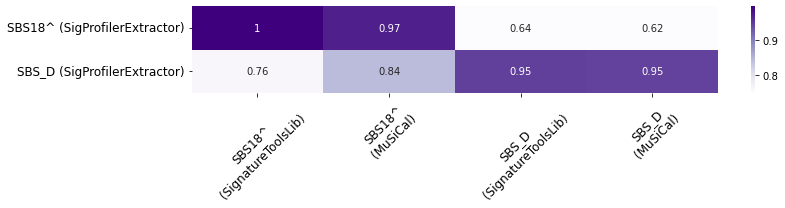

In [12]:
######### Supplementary Figure 2c #########

fig,ax = plt.subplots(figsize=(12,3))
sns.heatmap(forheatmap,
           vmin=.75,cmap='Purples',annot=True)

plt.xticks(rotation=45
          )

plt.yticks(rotation=0
          )


reset_labels = []
for label in ax.get_xticklabels():
    text = label.get_text()
    text = text.replace(' ','\n')
    reset_labels.append(text)    
ax.set_xticklabels(reset_labels)


for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(12)
    
plt.tight_layout()

# plt.savefig('reviewer_plots/musical_sigtoolslib.png',dpi=300)